This notebook is used to walk through building up an MAE using a subset of the Dec 17, 2023 Nore'easter data. Data is 239 images from epoch num: 1702827001820. The data was made in metashape using the most recent method of using camera extrinsics. The subset of data is one transect through time.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import os
import glob

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
#from tensorflow.keras.datasets import fashion_mnist (fake data)
from tensorflow.keras.models import Model
from PIL import Image
from scipy.io import loadmat

2026-06-10 13:04:20.933521: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# paths
MAE_datapath=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data"
rawdatapath=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/videos/Transect_y7_3/2yavg/transects_7.3_2.mat"
savepath=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/Figures/L2RaltR2L_results_prelim"

Load and prep data

In [3]:
# load in matfile and convert
raw_transects=loadmat(rawdatapath)
transects=raw_transects['ztran']
transect_df_raw=pd.DataFrame(transects) # convert to dataframe
print(transect_df_raw.shape)

(551, 239)


In [4]:
# NEED TO NORMALIZE DATA
all_vals=transect_df_raw.values.flatten()
all_vals=all_vals[~np.isnan(all_vals)]

min_elev=np.min(all_vals)
print("Minimum elev:", min_elev,"m")
max_elev=np.max(all_vals)
print("Max elev:", max_elev,"m")

def normalize(x):
    return (x-min_elev)/(max_elev-min_elev)
def denormalize(x):
    return x*(max_elev-min_elev)+min_elev

transect_df_norm=(transect_df_raw-min_elev)/(max_elev-min_elev)

Minimum elev: 0.5426249999999999 m
Max elev: 8.340777777777777 m


Define model and functions

In [5]:
# define model
# right now using a window length of 10 so need to build up back to 10, if size is a multiple of 8 it's much easier for building up
class Denoise(Model):
    def __init__(self,window_size):
        super(Denoise,self).__init__()
        self.window_size=window_size

        self.encoder=tf.keras.Sequential([
            layers.Input(shape=(window_size,2)), # changed from none
            layers.Conv1D(32,3,activation='relu',padding='same',strides=2),
            layers.Conv1D(16,3,activation='relu',padding='same',strides=2),
            layers.Conv1D(8,3,activation='relu',padding='same',strides=2) #maintain shape with strides=1
        ])

        self.decoder=tf.keras.Sequential([
            layers.Conv1DTranspose(8,3,strides=2,activation='relu',padding='same'),
            layers.Conv1DTranspose(16,3,strides=2,activation='relu',padding='same'),
            layers.Conv1DTranspose(32,3,strides=2,activation='relu',padding='same'),
            layers.Flatten(),
            layers.Dense(window_size,activation='sigmoid'),
            layers.Reshape((window_size,1))
            #layers.Conv1D(1,3,activation='sigmoid',padding='same'), #normalized output
            #layers.Cropping1D((0,6)) # builds up to 16, need length of 10
            #x=layers.Dense(10,activation='sigmoid')(x) 
        ])

    def call(self,x):
        encoded=self.encoder(x)
        decoded=self.decoder(encoded)
        return decoded
    
    def train_step(self,data):
        # to get input tensor (x_input,y) from .map() in mask
        x_input,y, mask,start_idx,t_step = data #(batch,10,2) (batch,10,1) (batch,10,1)

        #x_input,mask=masking_layer(x) # apply mask
        #x_masked=x_input[:,:,:2]
        with tf.GradientTape() as tape: 
            # forward pass using x_masked
            y_pred=self(x_input,training=True)
            # calc loss
            #mask=x_input[:,:,1:2] #grab mask from 2nd channel
            mse=tf.square(y_pred-y) #calc loss
            masked_mse=mse*(1.0 - mask) # masked loss
            loss=tf.reduce_sum(masked_mse)/(tf.reduce_sum(1.0-mask)+1e-6) # mean sq error over just masked points
            #base_loss=tf.reduce_sum(masked_mse)/(tf.reduce_sum(1.0-mask)+1e-6) # mean sq error over just masked points
            # edge matching loss
            #mask_diff=tf.abs(mask[:,1:,:] - mask[:,:-1,:]) # find exact edge indices
            #edge_weights=tf.pad(mask_diff,[[0,0],[1,0],[0,0]]) # back to full shape
            #edge_loss=tf.reduce_sum(mse*edge_weights)/(tf.reduce_sum(edge_weights)+1e-6)

            # combined loss
            #total_loss=base_loss+(2*edge_loss) # heavy emphasis on matching uo edges
        trainable_vars=self.trainable_variables
        gradients=tape.gradient(loss,trainable_vars)
        self.optimizer.apply_gradients(zip(gradients,trainable_vars))

        return{"loss":loss}
    
    def test_step(self,data):
         # to get input tensor
        x,y,mask,start_idx,t_step=data
        
        #x_input,mask=masking_layer(x) # apply mask
        #x_masked=x_input[:,:,:2]
        y_pred=self(x,training=False)

        #mask=x_input[:,:,1:2]
        mse=tf.square(y_pred-y) #calc loss
        masked_mse=mse*(1.0 - mask) # masked loss
        loss=tf.reduce_sum(masked_mse)/(tf.reduce_sum(1.0-mask)+1e-6) # mean sq error over just masked points

        return {"loss":loss}
        

    
#autoencoder=Denoise()
#autoencoder.compile(optimizer='adam',loss='mse')

def gap_mask(x,mask_ratio):
     #batch_size=tf.shape(x)[0]
     length=tf.shape(x)[0]# number of things in x, x is (10,1)

     gap_size=tf.cast(tf.cast(length,tf.float32)*mask_ratio,tf.int32) # how many elements to be masked (length of window*maskratio)
     gap_size=tf.maximum(gap_size,1) # no zero lengths aka at least one thing is masked
     max_start=tf.maximum(length-gap_size,0) #mask starts inside window

     start=tf.random.uniform([],minval=0,maxval=max_start+1,dtype=tf.int32) # random start of mask

     #mask=tf.ones_like((batch_size,length,1),dtype=tf.float32) # 1D mask (batch,length,1)

     #idx=tf.range(start,start+gap_size) # gap indices
     #idx=tf.expand_dims(idx,axis=1) #add dimension (block_size,1)
     range_idx=tf.range(length) # (length,) 
     #range_idx=tf.expand_dims(range_idx,0) #(1,length)
     #range_idx=tf.tile(range_idx,[batch_size,1]) # (batch, length)

     #start_extra_dim=tf.reshape(start,[batch_size,1]) # (batch,1)
     #boolean mask
     if_in_gap=tf.logical_and(range_idx>=start,range_idx<(start+gap_size))

     gap_mask_tensor=tf.cast(if_in_gap,tf.float32)
     gap_mask_tensor=tf.expand_dims(gap_mask_tensor,-1) # 1 at gap, 0 everywhere else (batch,length,1)
     mask=1-gap_mask_tensor
     #mask=1-tf.expand_dims(tf.cast(if_in_gap,tf.float32),axis=-1)# 0 is gap 1 is not (batch,length,1)
    
     #updates=tf.zeros((batch_size,gap_size,1),dtype=tf.float32)# zeros at made gaps
     #mask=tf.tensor_scatter_nd_update(mask,idx,updates)

     #batch_idx=tf.range(batch_size)
     #batch_idx=tf.expand_dims(batch_idx,-1) # (batch,1)
     #atch_idx=tf.tile(batch_idx,[1,gap_size]) # (batch,gap_size)

     #seq_idx=tf.tile(tf.expand_dims(idx,0),[batch_size,1]) #(batch, gap_size)

     #ndx=tf.stack([batch_idx,seq_idx],axis=-1) # (batch, gap_size, 2)

     #mask=tf.tensor_scatter_nd_update(mask,indx,updates)
     
     x_masked=x*mask
     return x_masked,mask

def random_mask(x,mask_ratio):
    #batch=tf.shape(x)[0]
    #length=tf.shape(x)[1]
    #shape=[tf.shape(x)[0],tf.shape(x)[1],1] # list [batch,length,1]
    mask=tf.cast(tf.random.uniform(tf.shape(x))>mask_ratio,tf.float32) # mask is is (batch,length,1) and x_masked is (batch,length,2)
    x_masked=x*mask
    return x_masked, mask


def masking_layer(x,start,t_step):
    #x=tf.expand_dims(x,axis=-1) if len(x.shape)==1 else x # (length,1)
    window_size=tf.shape(x)[0]
    #x=tf.expand_dims(x,axis=-1) if len(x.shape)==1 else x #check right shape or add dimension (length,1)
    #x=tf.expand_dims(x,axis=0) #(1,length)
    #x=tf.convert_to_tensor(x)
    x=tf.reshape(tf.cast(x,tf.float32),[window_size,1]) # 10 is window length
    mask_ratio=tf.random.uniform([],0.1,0.8) #mask possibilities of 10-80%

    use_gaps=tf.random.uniform([])<0.7 #random chosen number to use this mask method
    #mask via gap and random method
    x_masked,mask=tf.cond(use_gaps,lambda: gap_mask(x,mask_ratio),lambda: random_mask(x,mask_ratio))

    #x_masked=tf.convert_to_tensor(x_masked)
    #mask=tf.convert_to_tensor(mask)
    # mask as a second channel
    #if mask.shape.rank==1:
        #mask=tf.expand_dims(mask,axis=1)
    #mask=tf.tile(mask,[1,10,1])
    #mask.set_shape([10,1])
    #x_masked.set_shape([10,1])
    x_input=tf.concat([x_masked,mask],axis=-1) # now (1,length,2)

    #tf.print("running mask layer- x_masked shape:", tf.shape(x_masked))
    #tf.print("running masked layer- mask shape:", tf.shape(mask))


    return x_input,x, mask, start, t_step# (given data and target/real og data)


In [6]:
def run_MAE(window_size,df,split_windows_idx,epochs=20,batch_size=16):
    epoch_tracker=tf.Variable(0,dtype=tf.int32,trainable=False)

    # alternate fucntion
    def alternate_masking_layer(X,starts,tsteps):
        # flips over horizantal axis if odd (righ2left)
        is_right2left=tf.math.equal(tf.math.mod(epoch_tracker,2),1) # even 0(L2R) odd 1(R2L)
        X_processed=tf.cond(is_right2left, lambda:tf.reverse(X,axis=[0]),lambda:X)
        x_input,x_target,mask,out_start,out_t_step=masking_layer(X_processed,starts,tsteps)

        return x_input,x_target,mask,out_start,out_t_step
    
    timesteps=sorted(split_windows_idx.keys())
    n=len(timesteps)

    train_end=int(n*0.7)
    val_end=int(n*0.85)

    train_time=timesteps[:train_end] #slice to grab train/test/val
    val_time=timesteps[train_end:val_end]
    test_time=timesteps[val_end:]

    def grab_windows(time_list): #loop through list of timesteps grab columnmand store as numpy vector
        X, info = [],[]
        for t in time_list:
            transect=df[t].values
            for (start,stop) in split_windows_idx[t]: # windows of chosen size
                X.append(transect[start:stop])
                info.append({'timestep':t,'start':start,'stop':stop}) # store location to put back together
        return np.array(X, dtype="float32"), info
    
    X_train, info_train=grab_windows(train_time)
    X_val, info_val=grab_windows(val_time)
    X_test, info_test=grab_windows(test_time)

    # create ds function (mem efficient)
    def build_ds(X,info,is_training=False):
        starts=np.array([i['start'] for i in info]) # start points spatial
        tsteps=np.array([i['timestep'] for i in info]) # end points spatial
        ds=tf.data.Dataset.from_tensor_slices((X,starts,tsteps)) # arrays into TensorFlow tensor slice ds
        # mask over transect windows, process masks concureently, batches of 16, prep batch n+1 while working on current batch (efficiency)
        if is_training:
            mapped_ds=ds.map(alternate_masking_layer,num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size,drop_remainder=True).prefetch(tf.data.AUTOTUNE)
        else:
            mapped_ds=ds.map(masking_layer,num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size,drop_remainder=True).prefetch(tf.data.AUTOTUNE)
        return mapped_ds
    
    
    train_ds=build_ds(X_train,info_train,is_training=True)
    test_ds=build_ds(X_test,info_test,is_training=False)
    val_ds=build_ds(X_val,info_val,is_training=False)

    # inirialize model
    model=Denoise(window_size=window_size)
    model.compile(optimizer='adam')

    class EpochDirectionCallback(tf.keras.callbacks.Callback):
        def on_epoch_begin(self,epoch,logs=None):
            epoch_tracker.assign(epoch)
            direction='right2left' if epoch %2 !=0 else 'left2right'
            print(f"\n Epoch {epoch+1}:  Training direction: {direction}")

    print(f"Training started for window size: {window_size} (train shape: {X_train.shape})")
    history=model.fit(train_ds, validation_data=val_ds, epochs=epochs,callbacks=[EpochDirectionCallback()], verbose=1)
    return model, history, test_ds


In [7]:
def is_gap_too_big(mask,window_size):
    mask_str="".join(mask.astype(int).astype(str))
    return "0"*window_size in mask_str

In [8]:
def reconstruct_ds_with_MAE(model,current_df,active_mask_df,window_size,stride=1,direction='left2right'):
    # slides MAE over the transects alternating from left to right  and right to left to impute where gaps exist
    # returns newly filled dataset
    x_matrix=tf.convert_to_tensor(current_df.values,dtype=tf.float32) # dataframe to tensorflow float 32
    transect_pts,tsteps=x_matrix.shape # length or cross-shore, timesteps

    mask_matrix=active_mask_df.values.astype(np.float32)
    #raw_groundtruth=baseline_raw_df.values

    reconstructed_all=[]

    for i in range(tsteps): # loop through every time step
        x_1dim=x_matrix[:,i].numpy() #current transect
        mask_1dim=mask_matrix[:,i] #gaps present in og or prev reconstrcution

        valid_indices=np.where(mask_1dim==1.0)[0]
        if len(valid_indices)>0:
            last_valid_index=valid_indices[-1]
        else:
            last_valid_index=-1

        full_recon=np.zeros_like(x_1dim) 
        counts=np.zeros_like(x_1dim)
        #slide window over full transect
        for start in range(0,transect_pts-window_size+1,stride):
            end=start+window_size
            window_data=np.nan_to_num(x_1dim[start:end]) #any nans to 0
            window_mask=mask_1dim[start:end]

            if direction =='right2left':
                pred_window_data=np.flip(window_data)
                pred_window_mask=np.flip(window_mask)
            else:
                pred_window_data=window_data
                pred_window_mask=window_mask

            combined_input=np.stack([pred_window_data,pred_window_mask],axis=-1).reshape(1,window_size,2)

            # CHECKS
            is_already_full = np.all(window_mask == 1.0) # check if window is full
            has_gap_inside = np.any(window_mask == 0.0) #double check there actually is a gap inside to fix (at least 1 point)

            if is_already_full:# PATH1: do not predict if full of data
                #keep full window
                full_recon[start:end] = np.nansum([full_recon[start:end], window_data], axis=0)
                counts[start:end] += 1
                continue

            if has_gap_inside:
                gap_indices=np.where(window_mask==0.0)[0]
                total_real_data_pts=np.sum(window_mask==1.0)
                min_context_pts=1 #threshold of at least one point
                has_any_local_context=total_real_data_pts>=min_context_pts

                full_gap_idx=start+gap_indices[0]
                g_start=full_gap_idx
                if is_gap_too_big(window_mask,window_size=window_size):
                    #g_start=full_gap_idx
                    while g_start>0 and mask_1dim[g_start-1]==0.0:
                        g_start-=1
                    g_end=start+gap_indices[-1]
                    while g_end<transect_pts-1 and mask_1dim[g_end+1]==0.0:
                        g_end+=1
                    gap_size=g_end - g_start +1
                    print(f"gap size is {gap_size}")
                    if gap_size > window_size: # gap too big (outside of window)
                        print(f"t index {i} skipped gap ({start}:{end}) too large")
                        continue

            has_bounds=(window_mask[0]==1.0) and (window_mask[-1]==1.0)
            left_bound=(window_mask[0]==1.0) or (start>0 and mask_1dim[start-1]==1.0) #or (start==0)
            right_bound=(window_mask[-1]==1.0) or (end<transect_pts and mask_1dim[end]==1) #or (end==transect_pts)
            both_sides_bounded=left_bound or right_bound
            is_bounded=both_sides_bounded or has_bounds

            if has_any_local_context and is_bounded:
                model_recon = model.predict(combined_input, verbose=0).flatten()
                if direction=='right2left':
                    model_recon=np.flip(model_recon) # flip back
                    # keep original data
                recon_window=np.where(window_mask==1.0,window_data,model_recon) # keep og data
                    #preds for avg
                    #pred_only_window=np.where(window_mask==0.0,model_recon,0.0)
                full_recon[start:end] = np.nansum([full_recon[start:end], recon_window], axis=0)
                counts[start:end] += (window_mask==0.0).astype(float) # this only increments up where there are actual gap

        raw_prediction=np.divide(full_recon,counts,out=np.full_like(full_recon,np.nan),where=counts>0) # combine any overlapping predictions
        nan_indices=np.isnan(raw_prediction) # where gaps are missed bc at edge or too big of window

        # get rid of prediction into the abysss
        if last_valid_index !=-1 and last_valid_index<len(raw_prediction)-1:
            raw_prediction[last_valid_index+1:]=np.nan

        final_transect=raw_prediction.copy()
        is_gap=(mask_1dim==0) # find gap
        gap_changes=np.diff(is_gap.astype(int))

        gap_starts=np.where(gap_changes==1)[0]+1
        gap_ends=np.where(gap_changes==-1)[0]
        # at the edge
        if is_gap[0]: gap_starts= np.insert(gap_starts,0,0)
        if is_gap[-1]: gap_ends=np.append(gap_ends,len(is_gap)-1)
        # smooth over transistion (2-4 data points of smoothing with favor to the real data)
        blend_zone=min(4,int(window_size/4)) # transistion blending margin
        for g_start,g_end in zip(gap_starts,gap_ends):
            current_gap_size=g_end-g_start+1
            if current_gap_size<=6: # don't blend over the small gaps
                continue
            #left side blend
            if g_start>blend_zone:
                anchor_val=x_1dim[g_start -1] #known real value
                for b in range(blend_zone):
                    idx=g_start+b
                    if idx<= g_end and not np.isnan(raw_prediction[idx]):
                        # linear transition (Could do something better) from anchor to pred
                        alpha=(b+1)/(blend_zone +1)
                        final_transect[idx]=(1-alpha)*anchor_val+alpha*raw_prediction[idx]
            #right side
            if g_end< len(x_1dim)-1:
                right_anchor_idx=min(len(x_1dim)-1,g_end+1)
                if mask_1dim[right_anchor_idx]==1.0: 
                    anchor_val=x_1dim[g_end+1]
                    for b in range(blend_zone):
                        idx=g_end-b
                        if idx>=g_start and not np.isnan(raw_prediction[idx]):
                            alpha=(b+1)/(blend_zone+1)
                            final_transect[idx]=(1-alpha)*anchor_val+alpha*raw_prediction[idx]
        # overide to keep og data (kind of like a fail safe if the rest didn't work)
        final_transect=np.where(mask_1dim==1.0,x_1dim,final_transect)
        #plot_timestep_reconstruction(x_1dim, mask_1dim, full_recon, counts, final_transect, timestep_idx=i) # plot for debugging
        reconstructed_all.append(final_transect)
     # return dataframe (points, timesteps)
    return pd.DataFrame(np.stack(reconstructed_all,axis=1),columns=current_df.columns)


In [9]:
def window_split(start,stop,size,overlap):
    return[(i,i+size) for i in range(start,stop-size+1,int(overlap))]

In [10]:
def find_windows_of_data(df,window_size,overlap_stride):
    # find the continous sections of data and extract window indices
    window_idx={}
    for timestep,transect in df.items():
        arg=transect.values
        masked=np.ma.masked_invalid(arg)
        clumps=np.ma.clump_unmasked(masked)
        window_idx[timestep]=[(s.start,s.stop)for s in clumps]

    split_windows_idx={}
    for timestep in window_idx:
        new_windows=[]
        for (start,stop) in window_idx[timestep]:
            length=stop-start
            if length>= window_size:
                new_windows.extend(window_split(start,stop,window_size,overlap_stride))
        split_windows_idx[timestep]=new_windows

    return split_windows_idx


In [11]:
from collections import Counter
def reeval_and_hist(active_mask_df,min_length,target_val=0,plot_histogram=True,stage_label=""):
    # functiin to histogram after reconstruction
    mask_matrix=active_mask_df.values
    spatial_pts,tsteps=mask_matrix.shape
    all_window_lengths=[]

    for col in range(tsteps):
        column=mask_matrix[:,col]
        is_target=(column==target_val) # find zeros
        # pad edges to get everything
        bound=np.hstack(([False],is_target,[False]))
        diffs=np.diff(bound.astype(int))

        starts=np.where(diffs==1)[0]
        ends=np.where(diffs==-1)[0]
        lengths=ends-starts

        all_window_lengths.extend(lengths)

    filtered_lengths=[l for l in all_window_lengths if l>=min_length]

    freq_map=Counter(filtered_lengths)
    mode_size=freq_map.most_common(1)[0][0]

    print(f"mode: {mode_size}")
    print(f"max length: {max(filtered_lengths)}")
    print(f"min length: {min(filtered_lengths)}")

    if plot_histogram:
        plt.figure(figsize=(9,4))
        plt.hist(filtered_lengths,bins=np.arange(min(all_window_lengths)-0.5, max(all_window_lengths)+0.5,1),color='pink',edgecolor='deeppink',alpha=0.7)
        plt.axvline(mode_size,color='black',linestyle='--',linewidth=2,label=f'Mode:{mode_size}')
        plt.title(f'distribution of continous data segments')
        plt.xlabel('segment length')
        plt.ylabel('freq')
        plt.legend()
        plt.grid(axis='y',linestyle=':',alpha=0.6)
        plt.show()

        return mode_size


In [12]:
# plotting functions
from matplotlib.animation import FuncAnimation
def save_stage_comparison_plots(orig_full_df, recon_no_dune_df, window_size, stage_dir="stage_outputs"):
    """
    Plots and saves static comparisons showing the full profile (including dune),
    with the localized reconstructions overlaid at their proper positions.
    """
    os.makedirs(stage_dir, exist_ok=True)
    timesteps_to_plot = [0, 10, 20, 40, 60]
   
    # Define the spatial offset used during the .iloc[200:] slicing stage
    DUNE_OFFSET = 200
   
    for t in timesteps_to_plot:
        if t not in orig_full_df.columns:
            continue
           
        # 1. Grab the absolute raw baseline profile (including the dune)
        full_original = orig_full_df[t].values
        full_mask = ~np.isnan(full_original)
       
        # 2. Reconstruct the full coordinate line by stitching the original dune
        # together with the lower-beach patch provided by the current model stage
        full_reconstructed = full_original.copy()
       
        # Patch the trained window predictions over the lower-beach section
        # (This correctly aligns the model's indices starting from index 200 onward)
        full_reconstructed[DUNE_OFFSET:] = recon_no_dune_df[t].values

        plt.figure(figsize=(12, 4))
       
        # Plot the complete original line (dune + beach)
        plt.plot(full_original, color='blue', label='Original (with Dune)', alpha=0.8)
       
        # Overlay the reconstructed line
        plt.plot(full_reconstructed, color='deeppink', linewidth=2, linestyle='dashed',
                 label=f'Reconstructed (MAE-{window_size})')

        # Highlight missing gap regions across the entire profile layout
        plt.fill_between(
            np.arange(len(full_original)),
            np.nanmin(full_original) - 0.1,
            np.nanmax(full_original) + 0.1,
            where=~full_mask,
            color='gray',
            alpha=0.15,
            label='Missing Data Gap'
        )

        # Draw a vertical line denoting where the dune ends and the model zone begins
        plt.axvline(x=DUNE_OFFSET, color='black', linestyle=':', alpha=0.5, label='Dune Cutoff boundary')

        plt.title(f"Stage MAE-{window_size} Full Profile Reconstruction - Timestep {t}")
        plt.xlabel("Full Cross-shore index (Including Dune)")
        plt.ylabel("Normalized Elevation")
        plt.legend(loc='lower left')
        plt.tight_layout()
       
        # Save plot out
        plot_path = os.path.join(stage_dir, f"full_recon_stage_MAE{window_size}_timestep{t}.png")
        plt.savefig(plot_path, dpi=200)
        plt.close()


In [13]:
def save_stage_video_animation(orig_full_df, recon_no_dune_df, window_size, stage_dir="stage_outputs", interval=500):
    """
    Creates and saves a dynamic video tracking profile repairs over time,
    maintaining the unedited dune profile on the left.
    """
    os.makedirs(stage_dir, exist_ok=True)
   
    DUNE_OFFSET = 200
    orig_full_data = orig_full_df.values
    recon_no_dune_data = recon_no_dune_df.values
   
    n_points, n_timesteps = orig_full_data.shape
    x_coords = np.arange(n_points)

    fig, ax = plt.subplots(figsize=(12, 5))
   
    # Set standard layout constraints based on full dataset limits
    ax.set_xlim(0, n_points)
    ax.set_ylim(np.nanmin(orig_full_data) - 0.1, np.nanmax(orig_full_data) + 0.1)
    ax.set_xlabel("Full Cross-shore index")
    ax.set_ylabel("Normalized Elevation")
   
    # Initialize baseline handles
    line_recon, = ax.plot([], [], color='deeppink', linewidth=2, label=f'MAE-{window_size} Active Pass')
    line_orig, = ax.plot([], [], color='blue', alpha=0.6, label='Original Survey (with Dune)')
    #line_recon, = ax.plot([], [], color='deeppink', linewidth=2, label=f'MAE-{window_size} Active Pass')
   
    # Draw static divider indicator
    ax.axvline(x=DUNE_OFFSET, color='black', linestyle=':', alpha=0.4)
    ax.legend(loc='lower left')

    # gaps as highlights
    gap_spans=[]
    gap_patch=plt.Rectangle((0,0),1,1,fc="gray", alpha=0.3,label='gaps')
    ax.legend(handles=[line_orig,line_recon,gap_patch],loc='lower left')

    def update(frame):
        nonlocal gap_spans
        for span in gap_spans:
            span.remove()
        gap_spans.clear()
        y_orig = orig_full_data[:, frame]
       
        # Stitch the original dune to the model's currently filled lower beach
        y_recon_full = y_orig.copy()
        y_recon_full[DUNE_OFFSET:] = recon_no_dune_data[:, frame]

        is_gap=np.isnan(y_orig)
        is_gap[:DUNE_OFFSET]=False #ignore gaps in dune

        if np.any(is_gap):
            diff=np.diff(is_gap.astype(int))
            gap_starts=np.where(diff==1)[0]+1
            gap_ends=np.where(diff==-1)[0]+1

            if is_gap[0]:
                gap_starts=np.insert(gap_starts,0,0)
            if is_gap[-1]:
                gap_ends=np.append(gap_ends,n_points-1)

            for start,end in zip(gap_starts, gap_ends):
                span=ax.axvspan(start,end,color='gray',alpha=0.25,zorder=0)
                gap_spans.append(span)

       
        line_recon.set_data(x_coords, y_recon_full)
        line_orig.set_data(x_coords, y_orig)
        #line_recon.set_data(x_coords, y_recon_full)
       
        ax.set_title(f"Full Reconstruction | Stage: MAE-{window_size} | Timestep: {frame}")
        return [line_orig, line_recon] + gap_spans

    anim = FuncAnimation(fig, update, frames=n_timesteps, interval=interval, blit=True)
   
    video_path = os.path.join(stage_dir, f"full_profile_stage_MAE{window_size}.gif")
    anim.save(video_path, writer="pillow")
    plt.close()


In [14]:
# loss and error plotting functiosn
def save_stage_loss_plot(history, window_size, stage_dir="noreaster_stage_results"):
    """
    Plots and saves the training vs validation loss across epochs for a specific stage.
    """
    os.makedirs(stage_dir, exist_ok=True)
   
    plt.figure(figsize=(7, 4))
    plt.plot(history.history['loss'], label='Training Loss', color='teal', linewidth=2)
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='coral', linewidth=2, linestyle='--')
       
    plt.title(f"Stage MAE-{window_size} Learning Curves")
    plt.xlabel("Epochs")
    plt.ylabel("Loss (MSE)")
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
   
    plot_path = os.path.join(stage_dir, f"loss_curve_MAE{window_size}.png")
    plt.savefig(plot_path, dpi=200)
    plt.close()

In [15]:
def evaluate_and_plot_reconstruction_error(orig_no_dune_df, recon_no_dune_df, split_windows_idx, window_size, stage_dir="noreaster_stage_results"):
    """
    Calculates reconstruction metrics and generates spatial line and scatter plots,
    including the window-by-window scatter error distribution.
    """
    os.makedirs(stage_dir, exist_ok=True)
   
    y_true = orig_no_dune_df.values
    y_pred = recon_no_dune_df.values
    valid_mask = ~np.isnan(y_true)
   
    if not np.any(valid_mask):
        print(f"⚠️ Warning: No valid ground truth data found to calculate error metrics for MAE-{window_size}.")
        return {"rmse": np.nan, "mae": np.nan}
       
    # 1. Calculate global structural errors
    errors = y_pred[valid_mask] - y_true[valid_mask]
    rmse_global = np.sqrt(np.mean(errors**2))
    mae_global = np.mean(np.abs(errors))
   
    print(f"[Metrics MAE-{window_size}] RMSE: {rmse_global:.4f} | MAE: {mae_global:.4f}")
   
    # 2. Extract window-by-window MSE to power your custom scatter plot
    starts = []
    mse_window = []
   
    for timestep, intervals in split_windows_idx.items():
        if timestep not in orig_no_dune_df.columns:
            continue
        t_idx = list(orig_no_dune_df.columns).index(timestep)
       
        for (start, stop) in intervals:
            # Slices match the width of the active window processing layer
            window_true = y_true[start:stop, t_idx]
            window_pred = y_pred[start:stop, t_idx]
           
            # Isolate where we have valid data inside this window chunk
            w_mask = ~np.isnan(window_true)
            if np.any(w_mask):
                window_mse = np.mean((window_pred[w_mask] - window_true[w_mask]) ** 2)
                starts.append(start)
                mse_window.append(window_mse)

    # =========================================================================
    # YOUR INCORPORATED SCATTER PLOT
    # =========================================================================
    if len(mse_window) > 0:
        plt.figure(figsize=(10, 5))
        plt.scatter(starts, mse_window, alpha=0.5, c=mse_window, vmin=0, vmax=0.06, cmap='jet')
        plt.ylim([0, 0.02])
        plt.colorbar(label='mse per window of test')
        plt.axhline(np.mean(mse_window), color='deeppink', linestyle='--',
                    label=f'average mse per window ({np.mean(mse_window):.5f})')
       
        plt.title(f'reconstruction error of MAE{window_size} vs cross-shore position')
        plt.xlabel('cross-shore index (start of window)')
        plt.ylabel('MSE')
        plt.legend()
        plt.tight_layout()
       
        scatter_path = os.path.join(stage_dir, f"window_scatter_error_MAE{window_size}.png")
        plt.savefig(scatter_path, dpi=200)
        plt.close()
    # =========================================================================

    # 3. Traditional continuous Spatial MAE distribution plot
    spatial_mae = []
    spatial_coords = np.arange(y_true.shape[0])
   
    for idx in spatial_coords:
        row_mask = valid_mask[idx, :]
        if np.any(row_mask):
            row_err = np.abs(y_pred[idx, row_mask] - y_true[idx, row_mask])
            spatial_mae.append(np.mean(row_err))
        else:
            spatial_mae.append(np.nan)
           
    plt.figure(figsize=(10, 3.5))
    plt.plot(spatial_coords, spatial_mae, color='crimson', linewidth=1.8, label=f"MAE-{window_size} Spatial Deviation")
    plt.title(f"Reconstruction Error Distribution Across Profile (Stage MAE-{window_size})")
    plt.xlabel("Cross-shore index (No Dune)")
    plt.ylabel("Mean Absolute Error (Normalized)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
   
    line_plot_path = os.path.join(stage_dir, f"spatial_error_distribution_MAE{window_size}.png")
    plt.savefig(line_plot_path, dpi=200)

    return {"rmse":rmse_global,"mae":mae_global}


In [16]:
def plot_multistage_timestep_analysis(stages_dict, original_df, original_mask_df, timestep_to_plot, save_dir="stage_results"):
    """
    Plots a multi-panel spatial breakdown for a single timestep.
    Shows original data, inherited legacy reconstructions, and brand new stage
    reconstructions each in their own distinct colors per panel.
    """
    os.makedirs(save_dir, exist_ok=True)
   
    # Extract baseline elements for this specific timestep
    y_raw = original_df[timestep_to_plot].values
    mask_orig = original_mask_df[timestep_to_plot].values
    is_orig_nan = (mask_orig == 0.0) | (np.isnan(y_raw))
   
    x_full = np.arange(len(y_raw))
    stage_names = list(stages_dict.keys())
    num_stages = len(stage_names)
   
    # Establish unified vertical axis boundaries based on the original data range
    y_min = np.nanmin(original_df.values)
    y_max = np.nanmax(original_df.values)
    pad = (y_max - y_min) * 0.1
   
    # Create a stacked vertical subplot grid
    fig, axes = plt.subplots(num_stages, 1, figsize=(14, 3.8 * num_stages), sharex=True, sharey=True)
   
    if num_stages == 1:
        axes = [axes]
       
    # Style configuration for our categories
    color_original = '#2B2B2B'       # Dark Charcoal
    color_heritage = '#FF9F1C'       # Bright Orange/Gold for locked historical patches
    color_new_recon = 'deeppink'      # Crimson Red for brand new additions
   
    for idx, current_stage_name in enumerate(stage_names):
        ax = axes[idx]
       
        # Current stage full profile array
        y_current = stages_dict[current_stage_name][timestep_to_plot].values
       
        # 1. Background shading for reference
        ax.fill_between(
            x_full, y_min - pad, y_max + pad,
            where=is_orig_nan, color='gray', alpha=0.04,
            label='Initial Gap Zone' if idx == 0 else "", zorder=1
        )
       
        # 2. SEPARATE COMPONENT CALCULATIONS
        if idx == 0:
            # First stage: EVERYTHING filled in a gap is brand new
            y_new_only = np.where(is_orig_nan, y_current, np.nan)
            y_heritage_only = np.full_like(x_full, np.nan, dtype=float)
        else:
            # Subsequent stages: Look at what the PREVIOUS stage look like
            prior_stage_name = stage_names[idx - 1]
            y_prior = stages_dict[prior_stage_name][timestep_to_plot].values
           
            # Detect what gaps were already filled prior to this stage starting
            # (Where original was NaN, but prior stage managed to make a prediction)
            was_already_filled = is_orig_nan & (~np.isnan(y_prior))
           
            # Heritage data: Matches the prior stage's values inside those old gaps
            y_heritage_only = np.where(was_already_filled, y_prior, np.nan)
           
            # New data: Gaps where the prior stage had NO data (NaN), but the current stage filled it
            is_newly_filled = is_orig_nan & np.isnan(y_prior) & (~np.isnan(y_current))
            y_new_only = np.where(is_newly_filled, y_current, np.nan)

        # 3. PLOT DRAW SWEEPS
        # A. Plot legacy heritage shapes inherited from previous sizes
        if not np.all(np.isnan(y_heritage_only)):
            ax.plot(
                x_full, y_heritage_only,
                color=color_heritage, linewidth=2.0, linestyle='-',
                label='Previous Reconstruction', zorder=3
            )
           
        # B. Plot brand new patches generated specifically by this model size
        if not np.all(np.isnan(y_new_only)):
            ax.plot(
                x_full, y_new_only,
                color=color_new_recon, linewidth=2.5, linestyle='-',
                label=f'New Reconstruction ({current_stage_name})', zorder=4
            )
           
        # C. Plot the pristine baseline original measurements on top
        y_orig_only = np.where(~is_orig_nan, y_raw, np.nan)
        ax.plot(
            x_full, y_orig_only,
            color=color_original, linewidth=1.5,
            label='Original Data' if idx == 0 else "", zorder=5
        )
       
        # Panel decorations and styling
        ax.set_title(f" {idx + 1}: {current_stage_name}", fontsize=11, weight='bold', loc='left')
        ax.set_ylabel("Norm Elevation")
        ax.set_ylim(y_min - pad, y_max + pad)
        ax.grid(axis='y', linestyle=':', alpha=0.5)
        ax.legend(loc='upper right', ncol=4, framealpha=0.9, fontsize=9)
       
    axes[-1].set_xlabel("Cross-shore Index")
    plt.suptitle(f"Multi-Stage Evolution of MAE recon| Timestep: {timestep_to_plot}", fontsize=14, weight='bold', y=0.99)
    plt.tight_layout()
   
    save_path = os.path.join(save_dir, f"multistage_isolated_timestep_{timestep_to_plot}.png")
    plt.savefig(save_path, dpi=220)
    plt.show()

Train and run MAE

iteration 1, window size = 10
Training started for window size: 10 (train shape: (7593, 10))

 Epoch 1:  Training direction: left2right
Epoch 1/30
474/474 [==============================] - 2s 3ms/step - loss: 0.0092 - val_loss: 7.4390e-04

 Epoch 2:  Training direction: right2left
Epoch 2/30
474/474 [==============================] - 1s 3ms/step - loss: 6.0209e-04 - val_loss: 3.8462e-04

 Epoch 3:  Training direction: left2right
Epoch 3/30
474/474 [==============================] - 1s 3ms/step - loss: 2.4387e-04 - val_loss: 2.3483e-04

 Epoch 4:  Training direction: right2left
Epoch 4/30
474/474 [==============================] - 1s 3ms/step - loss: 1.2022e-04 - val_loss: 8.1001e-05

 Epoch 5:  Training direction: left2right
Epoch 5/30
474/474 [==============================] - 1s 3ms/step - loss: 1.0509e-04 - val_loss: 5.7665e-05

 Epoch 6:  Training direction: right2left
Epoch 6/30
474/474 [==============================] - 1s 3ms/step - loss: 9.6819e-05 - val_loss: 5.4408e-05

 Epo

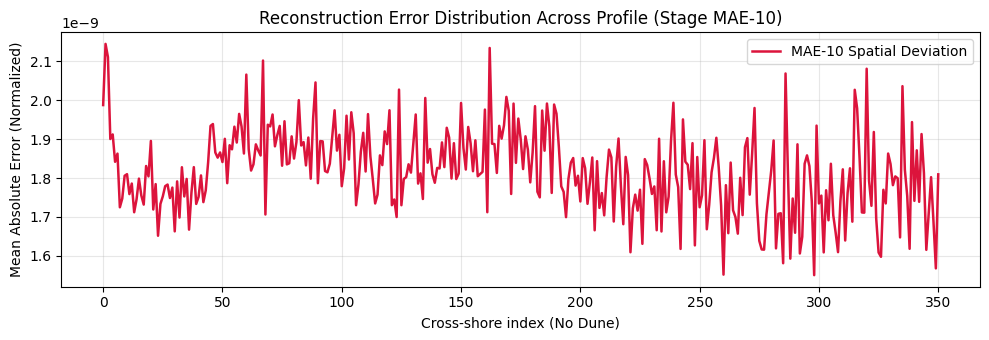

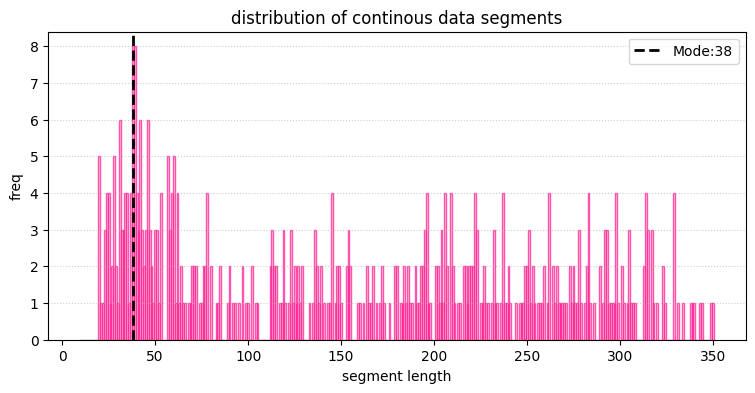

plotting static timesteps
video of reconstruction
iteration done, moving to size 38
iteration 2, window size = 38
Training started for window size: 38 (train shape: (2199, 38))

 Epoch 1:  Training direction: left2right
Epoch 1/30
137/137 [==============================] - 2s 9ms/step - loss: 0.0210 - val_loss: 0.0012

 Epoch 2:  Training direction: right2left
Epoch 2/30
137/137 [==============================] - 1s 8ms/step - loss: 9.2899e-04 - val_loss: 4.3818e-04

 Epoch 3:  Training direction: left2right
Epoch 3/30
137/137 [==============================] - 1s 8ms/step - loss: 7.2588e-04 - val_loss: 3.5387e-04

 Epoch 4:  Training direction: right2left
Epoch 4/30
137/137 [==============================] - 1s 8ms/step - loss: 6.9827e-04 - val_loss: 3.0457e-04

 Epoch 5:  Training direction: left2right
Epoch 5/30
137/137 [==============================] - 1s 9ms/step - loss: 6.9107e-04 - val_loss: 4.0563e-04

 Epoch 6:  Training direction: right2left
Epoch 6/30
137/137 [=============

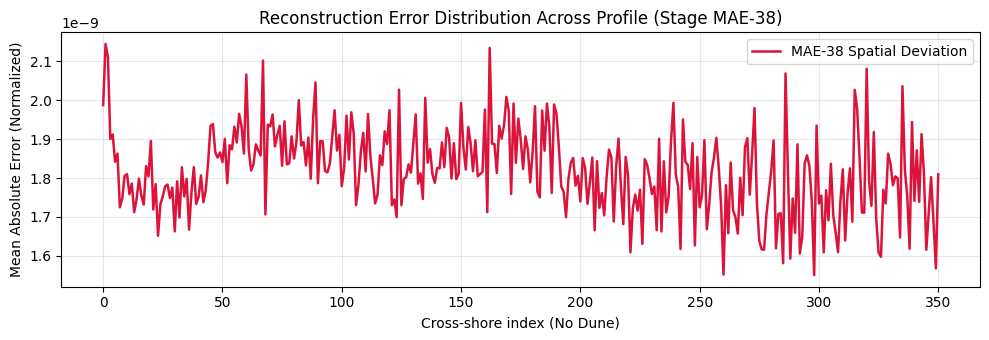

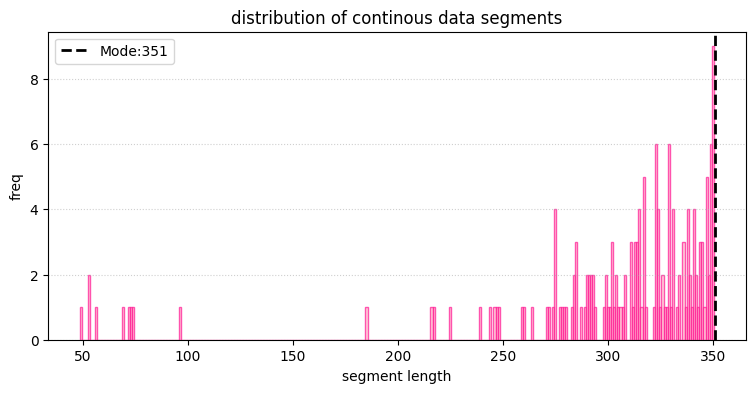

plotting static timesteps
video of reconstruction
iteration done, moving to size 351
iteration 3, window size = 88
Training started for window size: 88 (train shape: (957, 88))

 Epoch 1:  Training direction: left2right
Epoch 1/30
59/59 [==============================] - 2s 14ms/step - loss: 0.0384 - val_loss: 0.0034

 Epoch 2:  Training direction: right2left
Epoch 2/30
59/59 [==============================] - 1s 11ms/step - loss: 0.0015 - val_loss: 4.7370e-04

 Epoch 3:  Training direction: left2right
Epoch 3/30
59/59 [==============================] - 1s 11ms/step - loss: 8.8683e-04 - val_loss: 4.2860e-04

 Epoch 4:  Training direction: right2left
Epoch 4/30
59/59 [==============================] - 1s 11ms/step - loss: 8.3010e-04 - val_loss: 5.5554e-04

 Epoch 5:  Training direction: left2right
Epoch 5/30
59/59 [==============================] - 1s 11ms/step - loss: 8.1805e-04 - val_loss: 4.2368e-04

 Epoch 6:  Training direction: right2left
Epoch 6/30
59/59 [========================

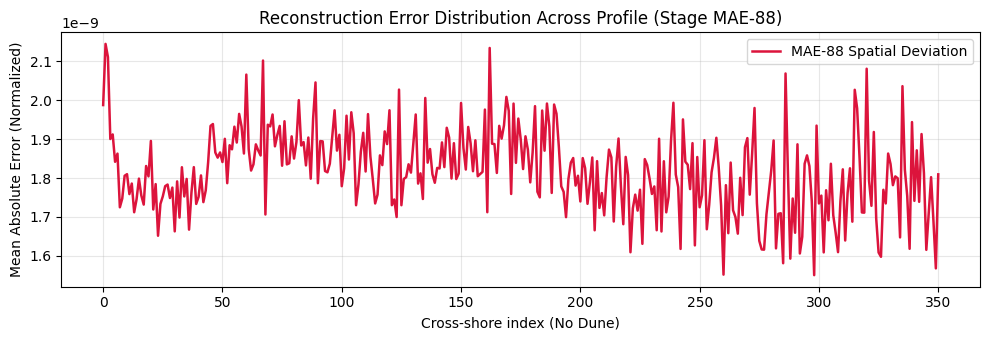

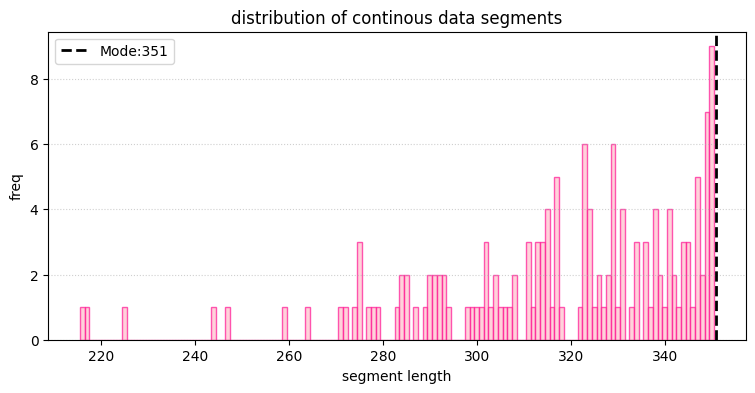

plotting static timesteps
video of reconstruction
iteration done, moving to size 351
iteration 4, window size = 138
Training started for window size: 138 (train shape: (577, 138))

 Epoch 1:  Training direction: left2right
Epoch 1/30
36/36 [==============================] - 2s 27ms/step - loss: 0.0549 - val_loss: 0.0047

 Epoch 2:  Training direction: right2left
Epoch 2/30
36/36 [==============================] - 1s 23ms/step - loss: 0.0045 - val_loss: 8.6409e-04

 Epoch 3:  Training direction: left2right
Epoch 3/30
36/36 [==============================] - 1s 21ms/step - loss: 0.0010 - val_loss: 6.3780e-04

 Epoch 4:  Training direction: right2left
Epoch 4/30
36/36 [==============================] - 1s 22ms/step - loss: 8.9661e-04 - val_loss: 4.1222e-04

 Epoch 5:  Training direction: left2right
Epoch 5/30
36/36 [==============================] - 1s 25ms/step - loss: 8.5746e-04 - val_loss: 5.5431e-04

 Epoch 6:  Training direction: right2left
Epoch 6/30
36/36 [=========================

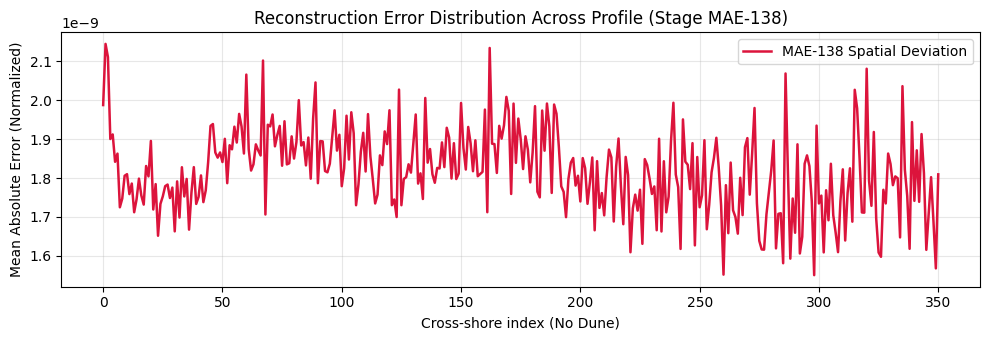

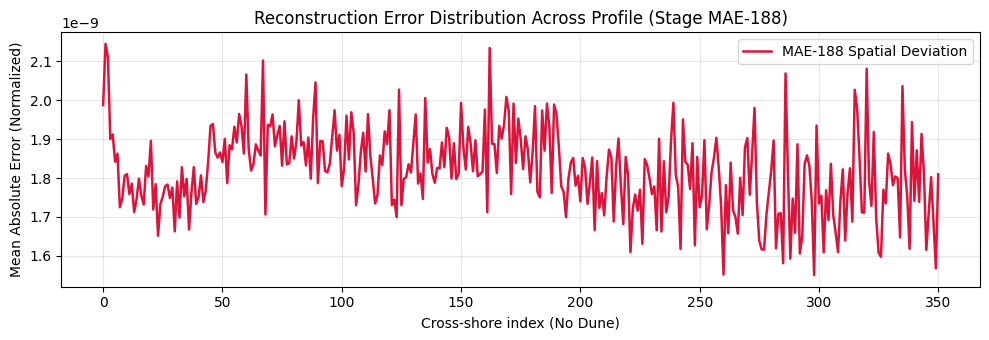

In [18]:
# workflow using re-histogram method
transect_df_norm_noDune=transect_df_norm.iloc[200:]
original_baseline_no_dune=transect_df_norm_noDune.copy()
current_dataset=original_baseline_no_dune.copy()
original_data_mask=(~np.isnan(current_dataset)).astype(float)
active_mask=(~np.isnan(current_dataset)).astype(float)

historical_stages_zoo={}

total_iterations=4
current_window_size=10 # start size

pipeline_history={}
summary_stats=[]

for iteration in range(1,total_iterations+1):
    print(f"iteration {iteration}, window size = {current_window_size}")

    # index map of gaps
    current_windows_idx=find_windows_of_data(current_dataset,window_size=current_window_size,overlap_stride=int(current_window_size/2))
    # train model
    trained_model,history,test_ds=run_MAE(window_size=current_window_size,df=current_dataset,split_windows_idx=current_windows_idx,epochs=30)
    # reconstruct transect
    reconstructed_df=reconstruct_ds_with_MAE(model=trained_model,current_df=current_dataset,active_mask_df=active_mask,window_size=current_window_size,stride=1,direction='right2left') # testing not keeping previous recons
    # store results
    stage_name=f"stage_{iteration}_size_{current_window_size}"
    historical_stages_zoo[stage_name]=reconstructed_df
    print("plotting error and loss")
    save_stage_loss_plot(history=history,window_size=current_window_size,stage_dir='stage_results')
    metrics=evaluate_and_plot_reconstruction_error(orig_no_dune_df=transect_df_norm_noDune,recon_no_dune_df=reconstructed_df,split_windows_idx=current_windows_idx,window_size=current_window_size,stage_dir='stage_results')

    summary_stats.append({'stage':f"MAE-{current_window_size}","RMSE":metrics["rmse"],"MAE":metrics["mae"]})
    #plot_reconstruction_matrix(current_df=current_dataset, active_mask_df=active_mask, filled_df=reconstructed_df, cmap='viridis', gap_color='deeppink')
    # update for loop
    current_dataset=reconstructed_df
    active_mask=(~np.isnan(current_dataset)).astype(float)
    stage_window=current_window_size
    # check next window size up
    if iteration<total_iterations:
        floor=current_window_size+10

        current_mode=reeval_and_hist(active_mask_df=active_mask,min_length=floor,target_val=1,plot_histogram=True,stage_label=f"post {stage_name}")

    if current_mode is not None:
        if current_mode<=current_window_size:
            current_window_size=current_window_size+15
        elif current_mode>=current_window_size+50: #keep from too big of a jump forward
            current_window_size=int(current_window_size+50) 
        else:
            current_window_size=int(current_mode)


    # save stats
    pipeline_history[stage_window]={"model":trained_model,"history":history,"dataset_after_stage": reconstructed_df.copy()}
    print("plotting static timesteps")
    save_stage_comparison_plots(orig_full_df=transect_df_norm, recon_no_dune_df=reconstructed_df,window_size=stage_window,stage_dir=savepath)
    print("video of reconstruction")
    save_stage_video_animation(orig_full_df=transect_df_norm,recon_no_dune_df=reconstructed_df,window_size=stage_window,stage_dir=savepath,interval=500)
    
    print(f"iteration done, moving to size {current_mode}")


#final stats
current_dataset=current_dataset
active_mask=(~np.isnan(current_dataset)).astype(float)

historical_stages_zoo["stage_final"]=current_dataset
final_metrics=evaluate_and_plot_reconstruction_error(orig_no_dune_df=transect_df_norm_noDune,recon_no_dune_df=current_dataset,split_windows_idx=current_windows_idx,window_size=current_window_size,stage_dir=savepath)
summary_stats.append({'stage': "final interpolation between small points", "RMSE" :final_metrics["rmse"],"MAE" : final_metrics["mae"]})
save_stage_video_animation(orig_full_df=transect_df_norm,recon_no_dune_df=current_dataset,window_size=current_window_size,stage_dir=savepath,interval=500)


In [19]:
df=pd.concat([transect_df_norm.iloc[:200],reconstructed_df],ignore_index=True)
df_un_norm=denormalize(df)
df.to_csv("/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/L2RaltR2L_transects_norm.csv",index=False)
df_un_norm.to_csv("/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/L2RaltR2L_transects.csv",index=False)